In [1]:
from cellosaurus_utils import *

brca_df, seqvar_df = get_cell_line_cellosaurus_annotations(file_dir=features_dir)
seqvar_df_filtered = filter_sequence_variation_modality(seqvar_df)

File 'cellosaurus.txt' already exists in /Users/fabring/Desktop/DeepMechanisticModels/features_newcv_newselect. Skipping download.


In [2]:
# Threshold: 20% of total rows[
threshold = 0.1 * len(seqvar_df)

# Count non-zero values per column
non_zero_counts = (seqvar_df > 0).sum(axis=0)

# Filter columns above threshold
frequent_columns = non_zero_counts[non_zero_counts > threshold].index.tolist()

frequent_columns

['CDH1_M', 'PIK3CA_M', 'TP53_M', 'PTEN_M']

In [3]:
non_zero_counts

CDH1_M         7
KRAS_M         4
MAP2K4_M       3
CDKN2A_D       5
PIK3CA_M      15
RB1_M          4
TP53_M        35
AHCTF1_F       1
DOK5_F         1
IKZF3_F        1
MRPL45_F       1
MYO9B_F        1
BRCA2_M        4
HNF1A_M        1
MAPK1_M        1
CLTC_F         2
PTEN_M         7
RRAS2_M        1
MAP2K4_D       1
RB1_D          1
APC_M          1
BRAF_M         4
ABCG1_F        1
FHIT_M         3
PTEN_D         1
BRCA1_M        3
TMPRSS2_M      2
GRK3_F         1
KDM6A_M        1
HRAS_M         2
MT-CYB_M       1
CDKN2B_D       2
GATA3_M        1
MSH6_M         1
NRG1_F         1
TERT_M         1
CDKN2A_M       1
AR_M           1
CHD4_M         1
RET_M          1
CDH1_D         1
APPBP2_F       1
ARHGAP32_F     1
BCAS3_F        1
COL14A1_F      1
CWC25_F        1
DDX5_F         1
ENPP2_F        1
LASP1_F        1
NRIP1_F        1
OPRD1_F        1
PCGF2_F        1
dtype: int64

# Train simple random forest regressor from sequence variations to `cytof_dynamic` and evaluate feature importances across splits

In [4]:
seqvar_df_filtered[frequent_columns]

,CDH1_M,PIK3CA_M,TP53_M,PTEN_M
cell_line,,,,
c184A1,0.0,0.0,0.0,0.0
c184B5,0.0,0.0,0.0,0.0
cBT20,0.0,0.5,1.0,0.0
cBT474,0.0,0.5,1.0,0.0
cBT483,0.0,0.5,0.5,0.0
cBT549,0.0,0.0,1.0,0.5
cCAL148,0.0,0.0,0.5,0.0
cCAL51,0.0,0.5,0.0,0.0
cCAL851,0.0,0.0,0.5,0.0


In [5]:
from common import training_samples, val_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from dmm.initialisation import impute_features
from sklearn.ensemble import RandomForestRegressor
from util import load_petab_base_files

np.random.seed(42)

for split in [f"{i}of5" for i in range(5)]:
    conf = Conf(model="EGFR_MAPK", data="dream_cytof", samples=split)
    samples_train, samples_val = training_samples(conf), val_samples(conf)

    inputs_train = seqvar_df_filtered.loc[samples_train]
    inputs_val = seqvar_df_filtered.loc[samples_val]

    petab_base_files = load_petab_base_files(conf)
    del petab_base_files["condition_table"]

    targets_train, features_train = load_data(
        contextualization="cytof_dynamic",
        samples=samples_train,
        features=None,
        **petab_base_files,
    )

    targets_val, _ = load_data(
        contextualization="cytof_dynamic",
        samples=samples_val,
        features=features_train,
        **petab_base_files,
    )

    assert inputs_val.index.values == targets_val.index.values

    targets = impute_features({"train": targets_train, "val": targets_val})
    targets_train, targets_val = targets["train"], targets["val"]

    rf = RandomForestRegressor()
    rf.fit(inputs_train, targets_train.values)

    train_pred = rf.predict(inputs_train)
    val_pred = rf.predict(inputs_val)

    train_rmse = np.sqrt(np.mean((train_pred - targets_train.values) ** 2))
    val_rmse = np.sqrt(np.mean((val_pred - targets_val.values) ** 2))
    print(f"Split: {split}, Training RMSE: {train_rmse:.3f}, Validation RMSE: {val_rmse:.3f}")

    importances = sorted(
        zip(inputs_train.columns, rf.feature_importances_),
        key=lambda x: x[1],
        reverse=True
    )[:5]

    for name, importance in importances:
        print(f"{name}: {importance:.4f}")


Split: 0of5, Training RMSE: 0.316, Validation RMSE: 0.596
TP53_M: 0.1880
PIK3CA_M: 0.1376
CDH1_M: 0.1272
BRAF_M: 0.1082
PTEN_M: 0.0946
Split: 1of5, Training RMSE: 0.318, Validation RMSE: 0.749
TP53_M: 0.2009
PIK3CA_M: 0.1511
CDH1_M: 0.1196
BRAF_M: 0.1079
PTEN_M: 0.0885
Split: 2of5, Training RMSE: 0.305, Validation RMSE: 0.799
TP53_M: 0.2106
PIK3CA_M: 0.1331
CDH1_M: 0.1167
CDKN2A_D: 0.1010
BRAF_M: 0.0921
Split: 3of5, Training RMSE: 0.320, Validation RMSE: 0.673
TP53_M: 0.1925
PIK3CA_M: 0.1503
BRAF_M: 0.0978
CDKN2A_D: 0.0950
CDH1_M: 0.0905
Split: 4of5, Training RMSE: 0.307, Validation RMSE: 0.771
TP53_M: 0.1914
PIK3CA_M: 0.1442
CDH1_M: 0.1141
BRAF_M: 0.0934
PTEN_M: 0.0886


## EDA - CelloSaurus

In [6]:
brca_df.columns

Index(['ID', 'Site', 'MS_Status', 'Disease', 'Sequence_Variation', 'CDH1',
       'KRAS', 'MAP2K4', 'CDKN2A', 'PIK3CA', 'RB1', 'TP53', 'AHCTF1', 'DOK5',
       'IKZF3', 'MRPL45', 'MYO9B', 'BRCA2', 'HNF1A', 'MAPK1', 'CLTC', 'PTEN',
       'RRAS2', 'APC', 'BRAF', 'ABCG1', 'FHIT', 'BRCA1', 'TMPRSS2', 'GRK3',
       'KDM6A', 'HRAS', 'MT-CYB', 'CDKN2B', 'GATA3', 'MSH6', 'NRG1', 'TERT',
       'AR', 'CHD4', 'RET', 'APPBP2', 'ARHGAP32', 'BCAS3', 'COL14A1', 'CWC25',
       'DDX5', 'ENPP2', 'LASP1', 'NRIP1', 'OPRD1', 'PCGF2'],
      dtype='object')

In [7]:
brca_df["Site"].unique()

array(['In situ; Breast, epithelium', 'In situ; Breast',
       'Metastatic; Pleural effusion', 'Metastatic; Skin',
       'Metastatic; Ascites', 'Unknown', 'Metastatic; Brain',
       'Metastatic; Pericardial effusion',
       'Metastatic; Axillary lymph node'], dtype=object)

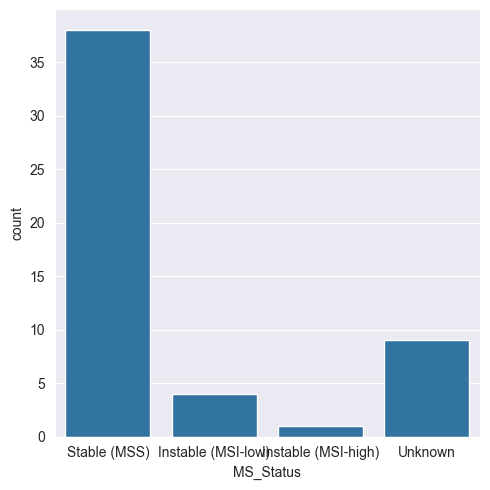

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(data=brca_df, x='MS_Status', kind='count', order=["Stable (MSS)", "Instable (MSI-low)", "Instable (MSI-high)", "Unknown"])

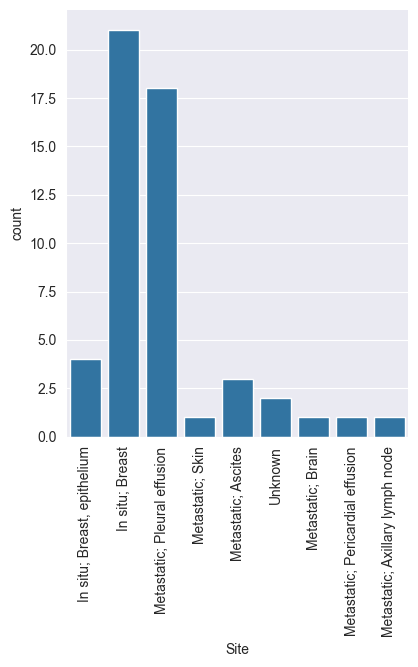

In [9]:
sns.catplot(data=brca_df, x='Site', kind='count')
plt.xticks(rotation=90);

Take a look at Instable cell-lines

In [10]:
brca_df[~brca_df["MS_Status"].isin(["Stable (MSS)", "Unknown"])]

,ID,Site,MS_Status,Disease,Sequence_Variation,CDH1,KRAS,MAP2K4,CDKN2A,PIK3CA,...,ARHGAP32,BCAS3,COL14A1,CWC25,DDX5,ENPP2,LASP1,NRIP1,OPRD1,PCGF2
cell_line,,,,,,,,,,,,,,,,,,,,,
cCAL51,CVCL_1110,Metastatic; Pleural effusion,Instable (MSI-low),Breast carcinoma,"[{'type': 'Mutation', 'gene': 'PIK3CA', 'hgnc_...",NaN,NaN,NaN,NaN,"M (p.Glu542Lys), Heterozygous",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cHCC1500,CVCL_1254,In situ; Breast,Instable (MSI-low),Breast ductal carcinoma,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cHCC1569,CVCL_1255,In situ; Breast,Instable (MSI-high),Breast ductal carcinoma,"[{'type': 'Mutation', 'gene': 'BRCA2', 'hgnc_i...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cOCUBM,CVCL_1621,Metastatic; Pleural effusion,Instable (MSI-low),Breast carcinoma,"[{'type': 'Mutation', 'gene': 'CHD4', 'hgnc_id...",NaN,NaN,NaN,NaN,"M (p.His1047Arg), Homozygous",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cZR7530,CVCL_1661,Metastatic; Ascites,Instable (MSI-low),Invasive breast carcinoma of no special type,"[{'type': 'Gene fusion', 'gene': 'APPBP2', 'hg...","M (p.Glu243Ter), Homozygous",NaN,NaN,NaN,NaN,...,F,F,F,F,F,F,F,F,F,F


Take a look at cell-lines for which we lack any kind of info/annotation

In [11]:
brca_df[(brca_df["MS_Status"] == "Unknown") | (brca_df["Site"] == "Unknown")]

,ID,Site,MS_Status,Disease,Sequence_Variation,CDH1,KRAS,MAP2K4,CDKN2A,PIK3CA,...,ARHGAP32,BCAS3,COL14A1,CWC25,DDX5,ENPP2,LASP1,NRIP1,OPRD1,PCGF2
cell_line,,,,,,,,,,,,,,,,,,,,,
c184B5,CVCL_4688,"In situ; Breast, epithelium",Unknown,Unknown,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cHBL100,CVCL_4362,Unknown,Stable (MSS),Unknown,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cHCC2185,CVCL_3375,Metastatic; Pleural effusion,Unknown,Metastatic breast lobular carcinoma,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cHCC3153,CVCL_3377,Unknown,Unknown,Breast ductal carcinoma,"[{'type': 'Gene fusion', 'gene': 'GRK3', 'hgnc...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cMCF12A,CVCL_3744,"In situ; Breast, epithelium",Unknown,Unknown,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cMDAMB134VI,CVCL_0617,Metastatic; Pleural effusion,Unknown,Invasive breast lobular carcinoma,"[{'type': 'Mutation', 'gene': 'CDH1', 'hgnc_id...","M (p.Leu230fs), Homozygous","M (p.Gly12Arg), Heterozygous","M (p.Ser184Leu), Homozygous",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cMPE600,CVCL_9875,Metastatic; Pleural effusion,Unknown,Invasive breast carcinoma of no special type,"[{'type': 'Mutation', 'gene': 'CDH1', 'hgnc_id...","M, Homozygous","M (p.Gly12Val), Heterozygous","M, Homozygous",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cMX1,CVCL_4774,In situ; Breast,Unknown,Breast carcinoma,"[{'type': 'Mutation', 'gene': 'TP53', 'hgnc_id...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cUACC3199,CVCL_4042,Metastatic; Axillary lymph node,Unknown,Invasive breast carcinoma of no special type,[{'type': 'Not Found'}],NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
brca_df["MS_Status"].value_counts()

MS_Status
Stable (MSS)           38
Unknown                 9
Instable (MSI-low)      4
Instable (MSI-high)     1
Name: count, dtype: int64

In [13]:
brca_df["Site"].value_counts()

Site
In situ; Breast                     21
Metastatic; Pleural effusion        18
In situ; Breast, epithelium          4
Metastatic; Ascites                  3
Unknown                              2
Metastatic; Skin                     1
Metastatic; Brain                    1
Metastatic; Pericardial effusion     1
Metastatic; Axillary lymph node      1
Name: count, dtype: int64

## `cbioportal` annotations

In [14]:
from cbio_py import cbio_mod as cb

In [15]:
cell_lines = [cell_line.lstrip("c") for cell_line in get_samples("dream_cytof")]
cbioportal_names = [cl + '_BREAST' for cl in cell_lines]

In [16]:
all_muts = cb.getMutationsInMolecularProfile(
    "ccle_broad_2019",
    "ccle_broad_2019",
    return_type="dict"
)

In [17]:
brca_muts = [mut for mut in all_muts if "BREAST" in mut["sampleId"]]

In [ ]:
cell_lines_ccle_names = [cell_line.upper() +"_BREAST" for cell_line in cell_lines]

In [ ]:
brca_mut_df = pd.DataFrame(brca_muts)
brca_mut_df["sampleId"] = brca_mut_df["sampleId"].apply(lambda x: x.split("_")[0])
brca_mut_df.to_csv(features_dir / "EGFR_MAPK/dream_cytof/cbioportal_ccle_broad2019_mutations_breast.csv")
brca_mut_df["gene"] = brca_mut_df["gene"].apply(lambda x: x["hugoGeneSymbol"])
brca_mut_df = brca_mut_df[
    ["chr", "entrezGeneId", "gene", "keyword", "mutationType", "sampleId", "proteinChange", "variantType"]
]
brca_mut_df.to_csv(features_dir / "EGFR_MAPK/dream_cytof/cbioportal_ccle_broad2019_mutations_breast_processed.csv")
brca_mut_df = brca_mut_df[brca_mut_df["sampleId"].isin([cell_line.upper() for cell_line in cell_lines])]

### We are missing mutation info for 10 cell-lines, of which 1 validation cell-lines (HCC-2185)
Checked by manually subsetting to `BREAST` on https://www.cbioportal.org/study/clinicalData?id=ccle_broad_2019

In [ ]:
brca_mut_df = pd.read_csv(
    features_dir / "EGFR_MAPK/dream_cytof/cbioportal_ccle_broad2019_mutations_breast_processed.csv"
)
brca_mut_df = brca_mut_df[brca_mut_df["sampleId"].isin([cell_line.upper() for cell_line in cell_lines])]
sorted([sample for sample in cell_lines if sample.upper() not in brca_mut_df.sampleId.unique()])

We can count the frequency/occurrence of unique mutations (gene / mutationType / variantType)

In [ ]:
brca_mut_df.groupby(["gene", "mutationType", "variantType"])["sampleId"].count().sort_values(ascending=False)

Or the occurrence of mutations in a particular gene altogether

In [ ]:
brca_mut_df.groupby(["gene"])["sampleId"].count().sort_values(ascending=False)

In [ ]:
gene_hit_count = brca_mut_df.groupby(["gene"])["sampleId"].count().sort_values(ascending=False)
gene_hit_count = gene_hit_count[gene_hit_count >= 4]
gene_list = gene_hit_count.index.tolist()

In [ ]:
ion_channel_genes = {
    ion: [gene for gene in gene_list if gene.startswith(pattern)]
    for ion, pattern in zip(
        ["sodium", "potassium", "potassium_2pore", "calcium", "chloride", "transient receptor potential", "hydrogen voltage gated channel"],
        ["SCN", "KCN", "KCNK", "CACN", "CLCN", "TRP", "HVCN"]
    )
}
ion_channel_genes

In [ ]:
ion_channel_gene_list = [x for xs in ion_channel_genes.values() for x in xs]

In [ ]:
signature_6ich = ["CACNA1C", "CACNA2D2", "CACNB2", "KCNJ11", "SCN3A", "SCN3B"]
[gene for gene in ion_channel_gene_list if gene in signature_6ich]

In [ ]:
brca_mut_df["gene"].value_counts().sort_values(ascending=False)

In [ ]:
brca_mut_df[brca_mut_df.gene.isin(ion_channel_gene_list)].groupby(["sampleId"])["gene"].apply(lambda x: list(x))

In [ ]:
brca_mut_df.groupby("sampleId")[["gene", "variantType"]].count()

In [ ]:
brca_mut_df.groupby("sampleId")[["gene"]].nunique()

In [ ]:
# Assuming brca_mut_df is already loaded
# Compute the number of unique (gene, variantType) pairs per sampleId
unique_combinations = brca_mut_df.groupby("sampleId")[["gene", "variantType"]].apply(lambda x: x.drop_duplicates().shape[0])

# Plot the results
plt.figure(figsize=(12, 6))
unique_combinations.sort_values(ascending=False, inplace=True)
# Define special colors for specific cell lines
highlight_samples = {"BT20": "red", "MCF7": "red", "HCC1500": "red", "EVSAT": "red"}
colors = [highlight_samples.get(sample, "blue") for sample in unique_combinations.index]
unique_combinations.plot(kind='bar', color=colors, edgecolor='black')

plt.xlabel("Sample ID")
plt.ylabel("Number of Unique (Gene, VariantType) Pairs / proxy for Tumour Mutation Burden (TMB)")
plt.title("Unique (Gene, VariantType) Combinations per Sample")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


In [ ]:
# Assuming brca_mut_df is already loaded
# Compute the number of unique mutated genes per sampleId
unique_combinations = brca_mut_df.groupby("sampleId")[["gene"]].apply(lambda x: x.drop_duplicates().shape[0])

# Plot the results
plt.figure(figsize=(12, 6))
unique_combinations.sort_values(ascending=False, inplace=True)
# Define special colors for specific cell lines
highlight_samples = {"BT20": "red", "MCF7": "red", "HCC1500": "red", "EVSAT": "red"}
colors = [highlight_samples.get(sample, "blue") for sample in unique_combinations.index]
unique_combinations.plot(kind='bar', color=colors, edgecolor='black')

plt.xlabel("Sample ID")
plt.ylabel("Number of Unique Mutated Genes / proxy for Tumour Mutation Burden (TMB)")
plt.title("Unique (Gene, VariantType) Combinations per Sample")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


In [ ]:
from gprofiler import GProfiler

# Initialize g:Profiler
gp = GProfiler(return_dataframe=True)

# Query GO enrichment
go_results = gp.profile(organism="hsapiens", query=gene_list, sources=["GO:BP", "GO:MF", "GO:CC"])

go_results[go_results.source == "GO:BP"].sort_values(by="term_size", ascending=False)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

significant_go = go_results[go_results["p_value"] < 0.05]

for source in ["GO:BP", "GO:MF", "GO:CC"]:
    # Select top enriched GO terms (Biological Process)
    top_go = significant_go[significant_go["source"] == source].sort_values("p_value").head(10)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.barh(top_go["name"], -np.log10(top_go["p_value"]))
    plt.xlabel("-log10(p-value)")
    plt.ylabel(f"{source}")
    plt.title(f"Top Enriched {source}")
    plt.gca().invert_yaxis()
    plt.show()

In [ ]:
# Query g:Profiler for pathway enrichment
gp = GProfiler(return_dataframe=True)
reactome_results = gp.profile(organism="hsapiens", query=gene_list, sources=["REAC"])

significant_reactome = reactome_results[reactome_results["p_value"] < 0.05]
# Select top enriched GO terms (Biological Process)
top_reac = significant_reactome.sort_values("p_value").head(10)

# Plot
plt.figure(figsize=(10, 5))
plt.barh(top_reac["name"], -np.log10(top_reac["p_value"]))
plt.xlabel("-log10(p-value)")
plt.ylabel("Reactome Annotations")
plt.title("Top Enriched Reactome Pathways")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Query g:Profiler for pathway enrichment
gp = GProfiler(return_dataframe=True)
kegg_results = gp.profile(organism="hsapiens", query=gene_list, sources=["KEGG"])

significant_kegg = kegg_results[kegg_results["p_value"] < 0.05]
# Select top enriched GO terms (Biological Process)
top_kegg = significant_kegg.sort_values("p_value").head(20)

# Plot
plt.figure(figsize=(10, 5))
plt.barh(top_kegg["name"], -np.log10(top_kegg["p_value"]))
plt.xlabel("-log10(p-value)")
plt.ylabel("KEGG Annotations")
plt.title("Top Enriched KEGG Pathways")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from common import hardest_cell_lines
hardest_cell_lines_ids = [cl[1:] for cl in hardest_cell_lines]
brca_mut_val = brca_mut_df[brca_mut_df.sampleId.isin(hardest_cell_lines_ids)]
brca_mut_val

In [ ]:
brca_mut_val.groupby(["keyword", "variantType"])[["sampleId"]].count().sort_values(by="sampleId", ascending=False)

In [ ]:
mutcount_df = brca_mut_df.dropna(subset=["keyword"]).groupby(["keyword", "variantType"])["sampleId"].count().reset_index().rename(columns={"sampleId": "mutCount"}).sort_values(by="mutCount", ascending=False)

In [ ]:
mutcount_df

In [ ]:
mutcount_df[mutcount_df.mutCount >= 4]

In [ ]:
brca_mut_df[(brca_mut_df["keyword"] == "TP53 truncating") & (brca_mut_df.sampleId == "HCC1569_BREAST")]

In [ ]:
plt.hist(brca_mut_df.groupby("keyword")["sampleId"].count().reset_index()["sampleId"].values)
plt.yscale("log")
plt.show()

In [ ]:
brca_mut_df.groupby("keyword")["sampleId"].count().reset_index()["sampleId"].values

In [ ]:
brca_filtered = brca_mut_df.dropna(subset=["keyword"])
brca_filtered = brca_filtered[brca_filtered["keyword"].str.contains("EGFR")]
brca_filtered